# Análise de Táxis Amarelos em Nova York

## Pergunta de Análise

Qual a média de valor total (**total_amount**) recebido em um mês considerando odos os yellow táxis da frota?",

### Contexto
Este notebook analisa os valores totais das corridas de táxis amarelos em Nova York para todos os mês disponíveis. O objetivo é entender a receita média por corrida, a distribuição ao longo dos meses e identificar padrões ou anomalias que possam indicar discrepâncias nos registros.

### Objetivo",
- Calcular a média de `total_amount` por corrida no mês analisado
- Visualizar a distribuição e tendência dos valores totais
- Identificar outliers e possíveis inconsistências nos registros


In [147]:
%pip install matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [149]:
from ifood.aws.athena_queries import execute_athena_query
from ifood.vars import athena_output_queries

In [150]:
athena_schema = "ifood_nyc_taxi_agency"
athena_table = "yellow_tripdata"

In [151]:
query = f"""
SELECT
    date_format(tpep_pickup_datetime, '%Y-%m') as month,
    ROUND(AVG(total_amount),2) AS average_total_amount
FROM {athena_schema}.{athena_table}
GROUP BY 1
ORDER BY 1
"""

In [152]:
execute_athena_query(query, athena_output_queries)

[{'month': '2001-01', 'average_total_amount': '56.28'},
 {'month': '2003-01', 'average_total_amount': '64.16'},
 {'month': '2008-12', 'average_total_amount': '60.88'},
 {'month': '2009-01', 'average_total_amount': '34.53'},
 {'month': '2014-11', 'average_total_amount': '52.38'},
 {'month': '2022-10', 'average_total_amount': '69.14'},
 {'month': '2022-12', 'average_total_amount': '13.72'},
 {'month': '2023-01', 'average_total_amount': '27.02'},
 {'month': '2023-02', 'average_total_amount': '26.89'},
 {'month': '2023-03', 'average_total_amount': '27.81'},
 {'month': '2023-04', 'average_total_amount': '28.24'},
 {'month': '2023-05', 'average_total_amount': '28.99'},
 {'month': '2023-06', 'average_total_amount': '28.26'},
 {'month': '2023-07', 'average_total_amount': '20.72'},
 {'month': '2023-08', 'average_total_amount': '25.68'},
 {'month': '2023-09', 'average_total_amount': '12.96'}]

In [153]:
query = f"""
SELECT
    date_format(tpep_pickup_datetime, '%Y-%m') as month,
    ROUND(AVG(total_amount),2) AS average_total_amount
FROM {athena_schema}.{athena_table}
WHERE date_format(tpep_pickup_datetime, '%Y-%m') BETWEEN '2023-01' AND '2023-05'
GROUP BY 1
ORDER BY 1
"""

In [154]:
execute_athena_query(query, athena_output_queries)

[{'month': '2023-01', 'average_total_amount': '27.02'},
 {'month': '2023-02', 'average_total_amount': '26.89'},
 {'month': '2023-03', 'average_total_amount': '27.81'},
 {'month': '2023-04', 'average_total_amount': '28.24'},
 {'month': '2023-05', 'average_total_amount': '28.99'}]

In [155]:
query = f"""
SELECT 
    date_format(tpep_pickup_datetime, '%Y-%m') as month,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM {athena_schema}.{athena_table}
WHERE date_format(tpep_pickup_datetime, '%Y-%m') < '2023-01'
GROUP BY 1,2
ORDER BY 1,2
"""

In [156]:
results = execute_athena_query(query, athena_output_queries)

In [157]:
results

[{'month': '2001-01',
  'source_date': '2023-03',
  'average_total_amount': '57.23',
  'total_trips': '3'},
 {'month': '2001-01',
  'source_date': '2023-04',
  'average_total_amount': '55.32',
  'total_trips': '3'},
 {'month': '2003-01',
  'source_date': '2023-03',
  'average_total_amount': '65.34',
  'total_trips': '5'},
 {'month': '2003-01',
  'source_date': '2023-04',
  'average_total_amount': '64.82',
  'total_trips': '2'},
 {'month': '2003-01',
  'source_date': '2023-05',
  'average_total_amount': '60.56',
  'total_trips': '2'},
 {'month': '2008-12',
  'source_date': '2023-03',
  'average_total_amount': '21.0',
  'total_trips': '1'},
 {'month': '2008-12',
  'source_date': '2023-04',
  'average_total_amount': '64.98',
  'total_trips': '1'},
 {'month': '2008-12',
  'source_date': '2023-05',
  'average_total_amount': '96.66',
  'total_trips': '1'},
 {'month': '2009-01',
  'source_date': '2023-01',
  'average_total_amount': '40.28',
  'total_trips': '2'},
 {'month': '2009-01',
  'sour

In [158]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['month', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['month', 'total_trips'], ascending=False)

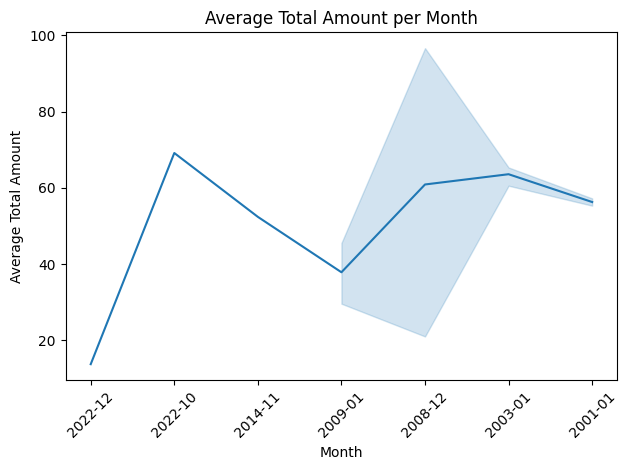

In [159]:
sns.lineplot(data=df_avg, x='month', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Month')
plt.xlabel('Month')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

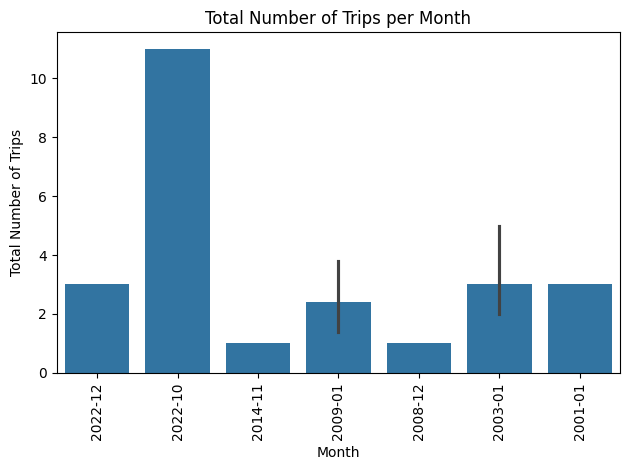

In [160]:
sns.barplot(data=df_trips, x='month', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Month')
plt.xlabel('Month')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [161]:
query = f"""
SELECT 
    date_format(tpep_pickup_datetime, '%Y-%m') as month,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM {athena_schema}.{athena_table}
WHERE date_format(tpep_pickup_datetime, '%Y-%m') > '2023-05'
GROUP BY 1,2
ORDER BY 1,2
"""

In [162]:
results = execute_athena_query(query, athena_output_queries)

In [163]:
results

[{'month': '2023-06',
  'source_date': '2023-05',
  'average_total_amount': '28.26',
  'total_trips': '18407'},
 {'month': '2023-07',
  'source_date': '2023-05',
  'average_total_amount': '20.72',
  'total_trips': '9'},
 {'month': '2023-08',
  'source_date': '2023-05',
  'average_total_amount': '25.68',
  'total_trips': '2'},
 {'month': '2023-09',
  'source_date': '2023-05',
  'average_total_amount': '12.96',
  'total_trips': '1'}]

In [164]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')

df_avg = df.sort_values(by=['month', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['month', 'total_trips'], ascending=False)

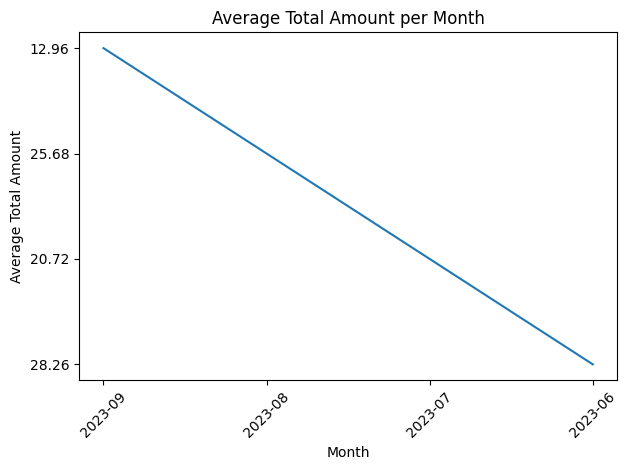

In [165]:
sns.lineplot(data=df_avg, x='month', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Month')
plt.xlabel('Month')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

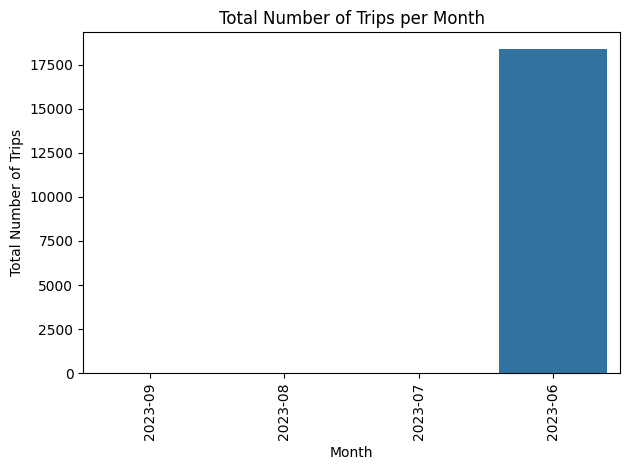

In [166]:
sns.barplot(data=df_trips, x='month', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Month')
plt.xlabel('Month')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [167]:
query = f"""
SELECT 
    date_format(tpep_pickup_datetime, '%Y-%m-%d') as pickup_date,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM {athena_schema}.{athena_table}
WHERE date_format(tpep_pickup_datetime, '%Y-%m') = '2023-06'
GROUP BY 1,2
ORDER BY 1,2
"""

In [168]:
results = execute_athena_query(query, athena_output_queries)

In [169]:
results

[{'pickup_date': '2023-06-01',
  'source_date': '2023-05',
  'average_total_amount': '28.26',
  'total_trips': '18397'},
 {'pickup_date': '2023-06-02',
  'source_date': '2023-05',
  'average_total_amount': '14.64',
  'total_trips': '1'},
 {'pickup_date': '2023-06-10',
  'source_date': '2023-05',
  'average_total_amount': '56.73',
  'total_trips': '2'},
 {'pickup_date': '2023-06-12',
  'source_date': '2023-05',
  'average_total_amount': '96.9',
  'total_trips': '1'},
 {'pickup_date': '2023-06-14',
  'source_date': '2023-05',
  'average_total_amount': '21.08',
  'total_trips': '4'},
 {'pickup_date': '2023-06-17',
  'source_date': '2023-05',
  'average_total_amount': '51.54',
  'total_trips': '2'}]

In [170]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['pickup_date', 'total_trips'], ascending=False)

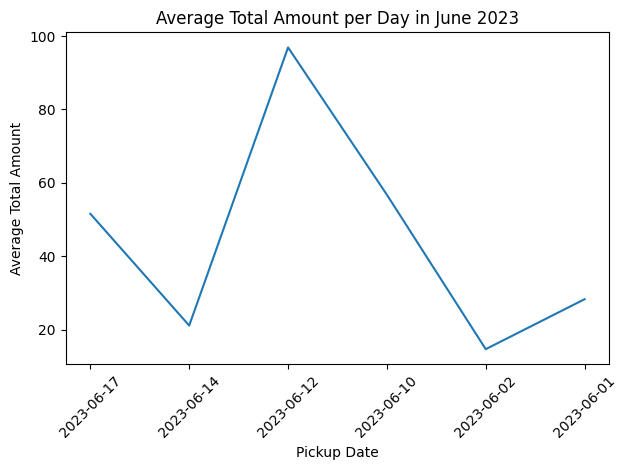

In [171]:
sns.lineplot(data=df_avg, x='pickup_date', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Day in June 2023')
plt.xlabel('Pickup Date')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

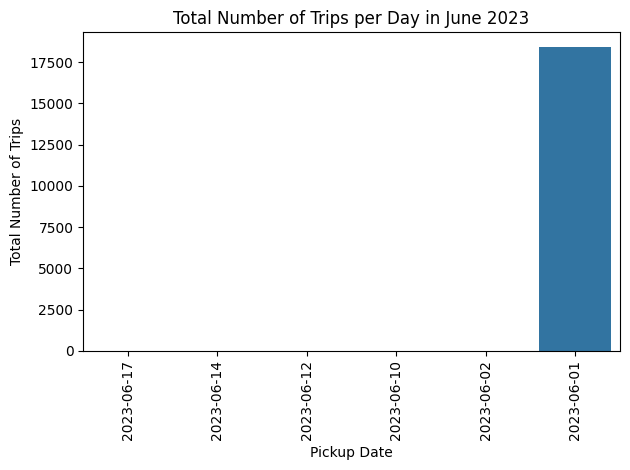

In [172]:
sns.barplot(data=df_trips, x='pickup_date', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Day in June 2023')
plt.xlabel('Pickup Date')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [173]:
query = f"""
SELECT 
    date_format(tpep_pickup_datetime, '%Y-%m-%d %H') as pickup_date_hour,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM {athena_schema}.{athena_table}
WHERE date_format(tpep_pickup_datetime, '%Y-%m-%d') = '2023-06-01'
GROUP BY 1,2
ORDER BY 1,2
"""

In [174]:
results = execute_athena_query(query, athena_output_queries)

In [175]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date_hour', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['pickup_date_hour', 'total_trips'], ascending=False)

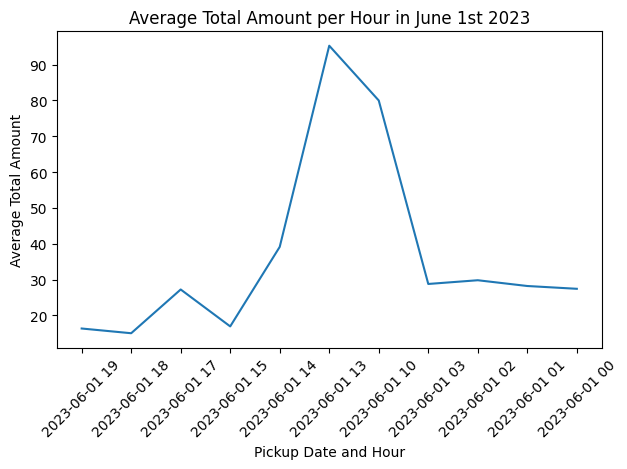

In [176]:
sns.lineplot(data=df_avg, x='pickup_date_hour', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Hour in June 1st 2023')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

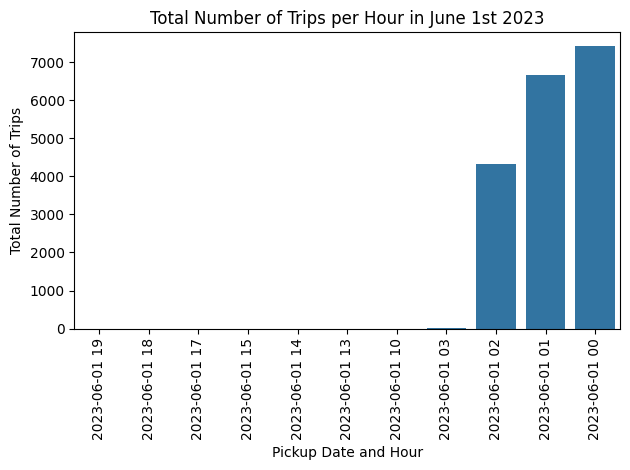

In [177]:
sns.barplot(data=df_trips, x='pickup_date_hour', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Hour in June 1st 2023')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [178]:
query = f"""
WITH normalize_datehour AS (
    SELECT 
        CASE WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:00' AND '2023-06-01 00:09' THEN '2023-06-01 00:00'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:10' AND '2023-06-01 00:19' THEN '2023-06-01 00:10'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:20' AND '2023-06-01 00:29' THEN '2023-06-01 00:20'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:30' AND '2023-06-01 00:39' THEN '2023-06-01 00:30'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:40' AND '2023-06-01 00:49' THEN '2023-06-01 00:40'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 00:50' AND '2023-06-01 00:59' THEN '2023-06-01 00:50'
        END as pickup_date_hour,
        source_date,
        total_amount
    FROM {athena_schema}.{athena_table}
    WHERE date_format(tpep_pickup_datetime, '%Y-%m-%d %H') = '2023-06-01 00'
)

SELECT 
    pickup_date_hour,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM normalize_datehour
GROUP BY 1,2
ORDER BY 1,2
"""

In [179]:
results = execute_athena_query(query, athena_output_queries)

In [180]:
results

[{'pickup_date_hour': '2023-06-01 00:00',
  'source_date': '2023-05',
  'average_total_amount': '25.69',
  'total_trips': '1182'},
 {'pickup_date_hour': '2023-06-01 00:10',
  'source_date': '2023-05',
  'average_total_amount': '27.14',
  'total_trips': '1261'},
 {'pickup_date_hour': '2023-06-01 00:20',
  'source_date': '2023-05',
  'average_total_amount': '28.04',
  'total_trips': '1268'},
 {'pickup_date_hour': '2023-06-01 00:30',
  'source_date': '2023-05',
  'average_total_amount': '27.53',
  'total_trips': '1291'},
 {'pickup_date_hour': '2023-06-01 00:40',
  'source_date': '2023-05',
  'average_total_amount': '27.7',
  'total_trips': '1201'},
 {'pickup_date_hour': '2023-06-01 00:50',
  'source_date': '2023-05',
  'average_total_amount': '28.31',
  'total_trips': '1209'}]

In [181]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date_hour', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['pickup_date_hour', 'total_trips'], ascending=False)

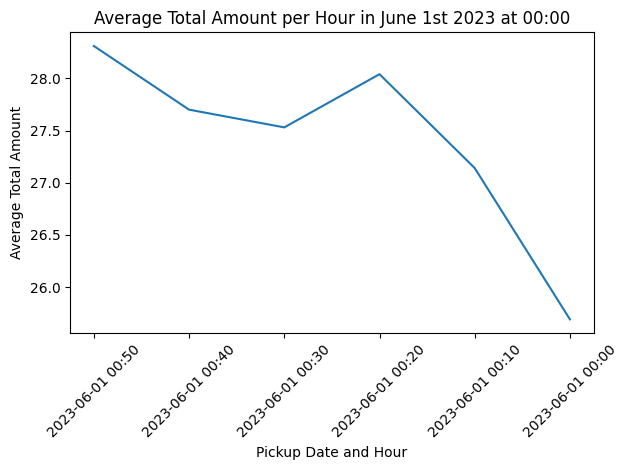

In [182]:
sns.lineplot(data=df_avg, x='pickup_date_hour', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Hour in June 1st 2023 at 00:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

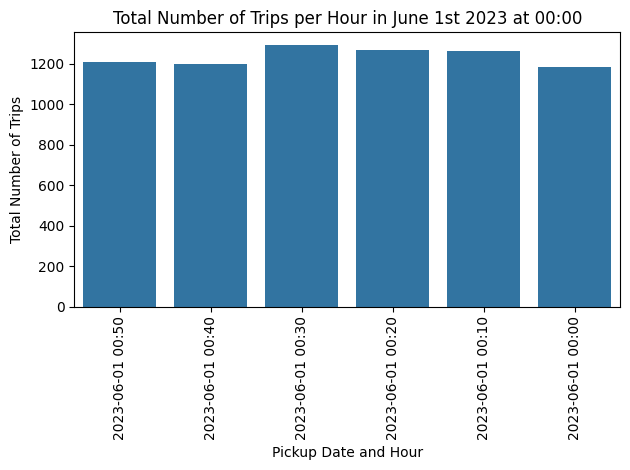

In [183]:
sns.barplot(data=df_trips, x='pickup_date_hour', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Hour in June 1st 2023 at 00:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [184]:
query = f"""
WITH normalize_datehour AS (
    SELECT 
        CASE WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:00' AND '2023-06-01 01:09' THEN '2023-06-01 01:00'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:10' AND '2023-06-01 01:19' THEN '2023-06-01 01:10'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:20' AND '2023-06-01 01:29' THEN '2023-06-01 01:20'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:30' AND '2023-06-01 01:39' THEN '2023-06-01 01:30'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:40' AND '2023-06-01 01:49' THEN '2023-06-01 01:40'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 01:50' AND '2023-06-01 01:59' THEN '2023-06-01 01:50'
        END as pickup_date_hour,
        source_date,
        total_amount
    FROM {athena_schema}.{athena_table}
    WHERE date_format(tpep_pickup_datetime, '%Y-%m-%d %H') = '2023-06-01 01'
)

SELECT 
    pickup_date_hour,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM normalize_datehour
GROUP BY 1,2
ORDER BY 1,2
"""

In [185]:
results = execute_athena_query(query, athena_output_queries)

In [186]:
results

[{'pickup_date_hour': '2023-06-01 01:00',
  'source_date': '2023-05',
  'average_total_amount': '26.32',
  'total_trips': '1208'},
 {'pickup_date_hour': '2023-06-01 01:10',
  'source_date': '2023-05',
  'average_total_amount': '28.54',
  'total_trips': '1158'},
 {'pickup_date_hour': '2023-06-01 01:20',
  'source_date': '2023-05',
  'average_total_amount': '27.55',
  'total_trips': '1092'},
 {'pickup_date_hour': '2023-06-01 01:30',
  'source_date': '2023-05',
  'average_total_amount': '28.01',
  'total_trips': '1050'},
 {'pickup_date_hour': '2023-06-01 01:40',
  'source_date': '2023-05',
  'average_total_amount': '29.46',
  'total_trips': '1104'},
 {'pickup_date_hour': '2023-06-01 01:50',
  'source_date': '2023-05',
  'average_total_amount': '29.47',
  'total_trips': '1041'}]

In [187]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date_hour', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['pickup_date_hour', 'total_trips'], ascending=False)

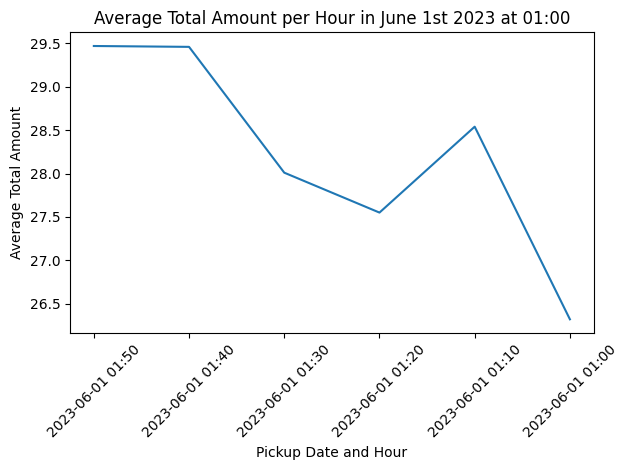

In [188]:
sns.lineplot(data=df_avg, x='pickup_date_hour', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Hour in June 1st 2023 at 01:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

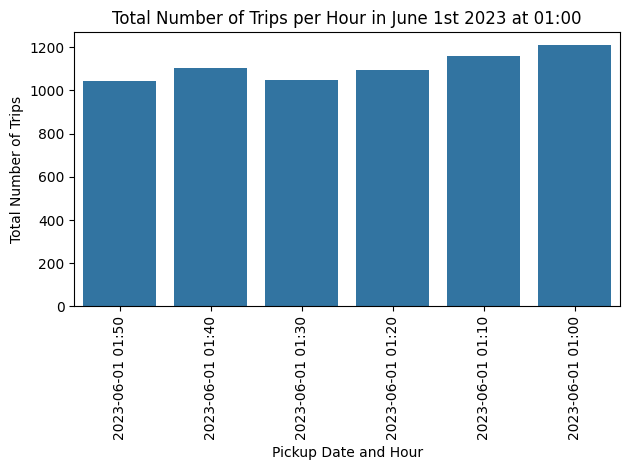

In [189]:
sns.barplot(data=df_trips, x='pickup_date_hour', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Hour in June 1st 2023 at 01:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()

In [190]:
query = f"""
WITH normalize_datehour AS (
    SELECT 
        CASE WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:00' AND '2023-06-01 02:09' THEN '2023-06-01 02:00'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:10' AND '2023-06-01 02:19' THEN '2023-06-01 02:10'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:20' AND '2023-06-01 02:29' THEN '2023-06-01 02:20'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:30' AND '2023-06-01 02:39' THEN '2023-06-01 02:30'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:40' AND '2023-06-01 02:49' THEN '2023-06-01 02:40'
             WHEN date_format(tpep_pickup_datetime, '%Y-%m-%d %H:%i') BETWEEN '2023-06-01 02:50' AND '2023-06-01 02:59' THEN '2023-06-01 02:50'
        END as pickup_date_hour,
        source_date,
        total_amount
    FROM {athena_schema}.{athena_table}
    WHERE date_format(tpep_pickup_datetime, '%Y-%m-%d %H') = '2023-06-01 02'
)

SELECT 
    pickup_date_hour,
    source_date,
    ROUND(AVG(total_amount),2) AS average_total_amount,
    ROUND(COUNT(1),2) AS total_trips
FROM normalize_datehour
GROUP BY 1,2
ORDER BY 1,2
"""

In [191]:
results = execute_athena_query(query, athena_output_queries)

In [192]:
results

[{'pickup_date_hour': '2023-06-01 02:00',
  'source_date': '2023-05',
  'average_total_amount': '29.11',
  'total_trips': '978'},
 {'pickup_date_hour': '2023-06-01 02:10',
  'source_date': '2023-05',
  'average_total_amount': '30.48',
  'total_trips': '857'},
 {'pickup_date_hour': '2023-06-01 02:20',
  'source_date': '2023-05',
  'average_total_amount': '30.91',
  'total_trips': '762'},
 {'pickup_date_hour': '2023-06-01 02:30',
  'source_date': '2023-05',
  'average_total_amount': '29.36',
  'total_trips': '643'},
 {'pickup_date_hour': '2023-06-01 02:40',
  'source_date': '2023-05',
  'average_total_amount': '28.35',
  'total_trips': '559'},
 {'pickup_date_hour': '2023-06-01 02:50',
  'source_date': '2023-05',
  'average_total_amount': '30.42',
  'total_trips': '518'}]

In [193]:
df = pd.DataFrame(results)
df['total_trips'] = pd.to_numeric(df['total_trips'], errors='coerce')
df['average_total_amount'] = pd.to_numeric(df['average_total_amount'], errors='coerce', downcast='float')

df_avg = df.sort_values(by=['pickup_date_hour', 'average_total_amount'], ascending=False)
df_trips = df.sort_values(by=['pickup_date_hour', 'total_trips'], ascending=False)

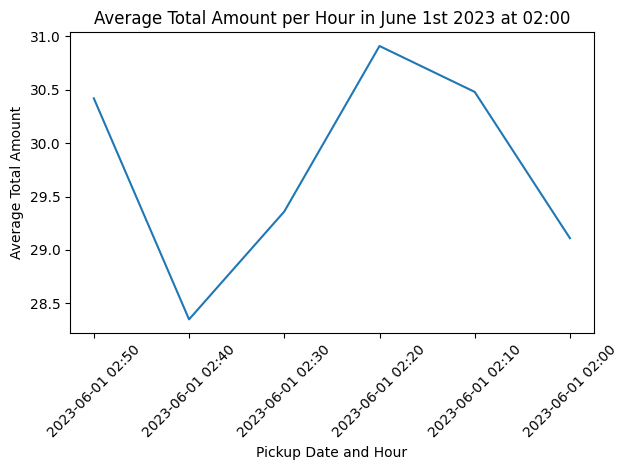

In [194]:
sns.lineplot(data=df_avg, x='pickup_date_hour', y='average_total_amount')
plt.xticks(rotation=45)
plt.title('Average Total Amount per Hour in June 1st 2023 at 02:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

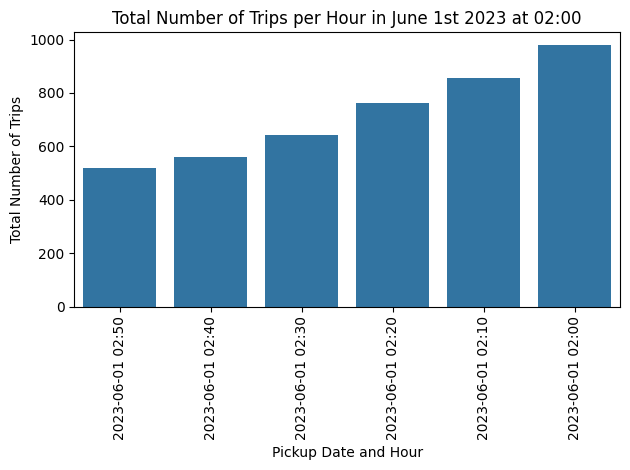

In [195]:
sns.barplot(data=df_trips, x='pickup_date_hour', y='total_trips')
plt.xticks(rotation=90)
plt.title('Total Number of Trips per Hour in June 1st 2023 at 02:00')
plt.xlabel('Pickup Date and Hour')
plt.ylabel('Total Number of Trips')
plt.tight_layout()
plt.show()